# 03 — Procedure Taxonomy

The initial analysis lumped 82% of admissions as "Other/Conservative."
This notebook breaks down all 193 procedure codes into 7 meaningful categories
and reveals that 42.7% of admissions are already surgical.

**Sources FINDINGS.md**: Section 2 (Corrected Procedure Taxonomy), Root Cause of Growth

In [1]:
import sys; sys.path.insert(0, ".")
from shared import *
import matplotlib.pyplot as plt
import seaborn as sns
import json, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

kidney = load_kidney()
recent = kidney[kidney["year"] >= 2022].copy()
print(f"Total records: {len(kidney):,} | Recent (2022+): {len(recent):,}")

Total records: 206,500 | Recent (2022+): 108,697


## Full procedure breakdown (top 20 of 193 codes)

In [2]:
proc_stats = kidney.groupby("PROC_REA").agg(
    n=("DIAG_PRINC", "count"),
    avg_los=("DIAS_PERM", "mean"),
    avg_cost=("VAL_TOT", "mean"),
    pct_emergency=("is_emergency", "mean"),
    mortality=("MORTE", "mean"),
).sort_values("n", ascending=False)
proc_stats["pct"] = proc_stats["n"] / len(kidney) * 100

print(f"Total unique procedure codes: {len(proc_stats)}\n")
print("Top 20 procedures:")
for proc, r in proc_stats.head(20).iterrows():
    name = PROC_NAMES.get(proc, proc)
    print(f"  {proc} {name:<40s} n={r['n']:>6.0f} ({r['pct']:5.1f}%)  "
          f"LOS {r['avg_los']:.1f}d  R${r['avg_cost']:.0f}  ER {r['pct_emergency']*100:.0f}%  death {r['mortality']*100:.2f}%")

Total unique procedure codes: 193

Top 20 procedures:
  0409010170 Open Ureterolithotomy                    n= 40973 ( 19.8%)  LOS 3.1d  R$735  ER 71%  death 0.78%
  0305020021 Diagnostic Imaging (Urography)           n= 40657 ( 19.7%)  LOS 2.7d  R$367  ER 94%  death 0.18%
  0409010596 Ureteroscopy (modern)                    n= 34036 ( 16.5%)  LOS 1.9d  R$1188  ER 35%  death 0.16%
  0415010012 Clinical Management                      n= 23275 ( 11.3%)  LOS 2.4d  R$1508  ER 36%  death 0.33%
  0415020034 Surgical Management                      n= 20597 ( 10.0%)  LOS 2.2d  R$1244  ER 50%  death 0.21%
  0409010561 Ureteral Catheter                        n= 13145 (  6.4%)  LOS 2.5d  R$1147  ER 51%  death 0.21%
  0409010235 Pyelolithotomy                           n=  8040 (  3.9%)  LOS 3.3d  R$1357  ER 12%  death 0.12%
  0301060070 ER Observation                           n=  5851 (  2.8%)  LOS 0.5d  R$122  ER 45%  death 0.03%
  0301060088 Clinical Care (short)                    n=  296

## 7-category taxonomy

In [3]:
cat_stats = kidney.groupby("proc_category").agg(
    n=("DIAG_PRINC", "count"),
    avg_los=("DIAS_PERM", "mean"),
    avg_cost=("VAL_TOT", "mean"),
    total_cost=("VAL_TOT", "sum"),
    pct_emergency=("is_emergency", "mean"),
    mortality=("MORTE", "mean"),
).sort_values("n", ascending=False)
cat_stats["pct"] = cat_stats["n"] / len(kidney) * 100

print("=== Procedure Categories ===\n")
print(f"{'Category':<20} {'Count':>7} {'%':>6} {'AvgLOS':>7} {'AvgCost':>8} {'ER%':>5} {'Death%':>7}")
print("-" * 70)
for cat, r in cat_stats.iterrows():
    print(f"{cat:<20} {r['n']:>7.0f} {r['pct']:>5.1f}% {r['avg_los']:>6.1f}d "
          f"R${r['avg_cost']:>7.0f} {r['pct_emergency']*100:>4.0f}% {r['mortality']*100:>6.2f}%")

=== Procedure Categories ===

Category               Count      %  AvgLOS  AvgCost   ER%  Death%
----------------------------------------------------------------------
SURGICAL               88681  42.9%    2.6d R$    983   49%   0.46%
DIAGNOSTIC             41487  20.1%    2.7d R$    369   94%   0.19%
CLINICAL_MGMT          23275  11.3%    2.4d R$   1508   36%   0.33%
SURGICAL_MGMT          20597  10.0%    2.2d R$   1244   50%   0.21%
INTERVENTIONAL         20113   9.7%    2.1d R$    977   42%   0.17%
OBSERVATION             8818   4.3%    0.6d R$    135   57%   0.10%
OTHER                   3529   1.7%    4.0d R$   1074   65%   1.79%


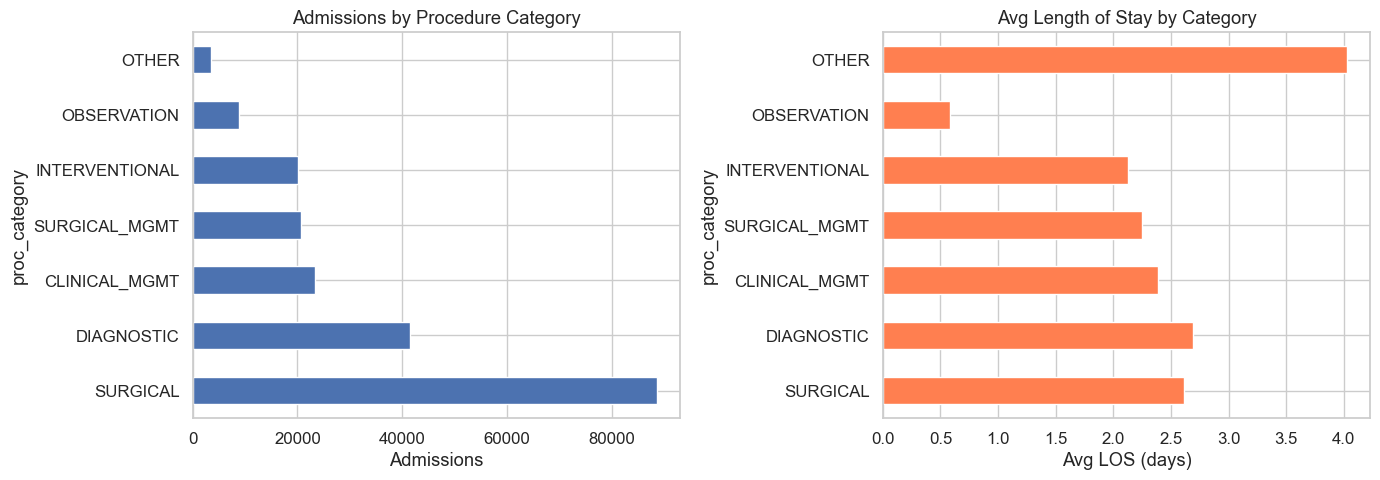

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_stats["n"].plot.barh(ax=axes[0])
axes[0].set_xlabel("Admissions")
axes[0].set_title("Admissions by Procedure Category")

cat_stats["avg_los"].plot.barh(ax=axes[1], color="coral")
axes[1].set_xlabel("Avg LOS (days)")
axes[1].set_title("Avg Length of Stay by Category")

plt.tight_layout()
plt.savefig(PLOT_DIR / "03_procedure_categories.png", dpi=150, bbox_inches="tight")
plt.show()

## Within surgery: modern vs traditional

In [5]:
surgical = kidney[kidney["proc_category"] == "SURGICAL"].copy()
surgical.loc[surgical["PROC_REA"].isin(SURGERY_TYPE_MAP.keys()) == False, "surgery_type"] = "Traditional (open)"

surg_comp = surgical.groupby("surgery_type").agg(
    n=("DIAG_PRINC", "count"),
    avg_los=("DIAS_PERM", "mean"),
    median_los=("DIAS_PERM", "median"),
    avg_cost=("VAL_TOT", "mean"),
    pct_emergency=("is_emergency", "mean"),
    mortality=("MORTE", "mean"),
).sort_values("avg_los")

print("=== Surgical Subtypes ===\n")
print(f"{'Type':<30} {'Count':>7} {'AvgLOS':>7} {'MedLOS':>7} {'AvgCost':>8} {'ER%':>5} {'Death%':>7}")
print("-" * 80)
for t, r in surg_comp.iterrows():
    print(f"{t:<30} {r['n']:>7.0f} {r['avg_los']:>6.1f}d {r['median_los']:>6.0f}d "
          f"R${r['avg_cost']:>7.0f} {r['pct_emergency']*100:>4.0f}% {r['mortality']*100:>6.2f}%")

=== Surgical Subtypes ===

Type                             Count  AvgLOS  MedLOS  AvgCost   ER%  Death%
--------------------------------------------------------------------------------
ESWL (lithotripsy)                2784    0.9d      0d R$    668   18%   0.04%
Ureteroscopy (modern)            34036    1.9d      1d R$   1188   35%   0.16%
Traditional (open)               51861    3.2d      2d R$    866   59%   0.68%


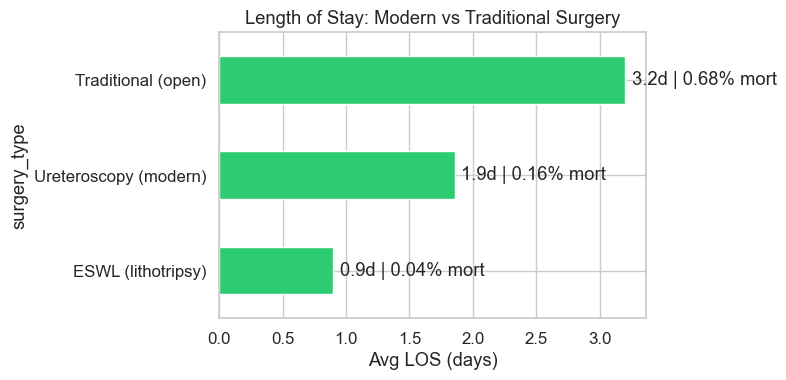

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
surg_comp[["avg_los"]].plot.barh(ax=ax, legend=False, color=["#2ecc71", "#3498db", "#e74c3c"])
ax.set_xlabel("Avg LOS (days)")
ax.set_title("Length of Stay: Modern vs Traditional Surgery")
for i, (_, r) in enumerate(surg_comp.iterrows()):
    ax.text(r["avg_los"] + 0.05, i, f'{r["avg_los"]:.1f}d | {r["mortality"]*100:.2f}% mort', va="center")
plt.tight_layout()
plt.savefig(PLOT_DIR / "03_surgery_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Growth decomposition by procedure

Admissions by year and category:
proc_category  CLINICAL_MGMT  DIAGNOSTIC  INTERVENTIONAL  OBSERVATION  OTHER  SURGICAL  SURGICAL_MGMT
year                                                                                                 
2015                      95         144              84           22     13       219             63
2016                    1591        3853            2269          678    282      4349           1212
2017                    1561        4037            2366          641    311      4576           1510
2018                    1864        4251            2621          810    281      4629           1906
2019                    2104        4225            2838          853    342      5104           2291
2020                    1916        3624            2840          794    287      4932           2271
2021                    2011        3275            1693          802    315      6909           2139
2022                    2497        3940         

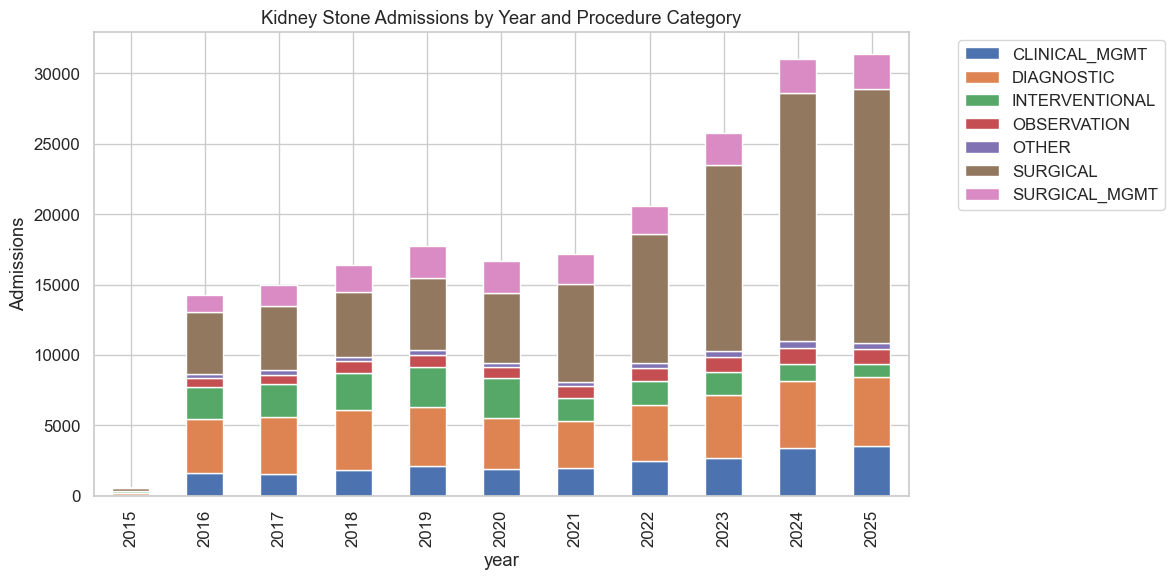

In [7]:
yearly_proc = kidney.groupby(["year", "proc_category"]).size().unstack(fill_value=0)
print("Admissions by year and category:")
print(yearly_proc.to_string())

fig, ax = plt.subplots(figsize=(12, 6))
yearly_proc.plot.bar(stacked=True, ax=ax)
ax.set_ylabel("Admissions")
ax.set_title("Kidney Stone Admissions by Year and Procedure Category")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(PLOT_DIR / "03_growth_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

## Access gap: cities with vs without ureteroscopy

In [8]:
cities_with_uretero = set(recent[recent["has_new_proc"] == 1]["MUNIC_MOV"].unique())
all_cities = set(recent["MUNIC_MOV"].unique())

patients_with = recent[recent["MUNIC_MOV"].isin(cities_with_uretero)]
patients_without = recent[~recent["MUNIC_MOV"].isin(cities_with_uretero)]

migration_with = patients_with[patients_with["MUNIC_MOV"].isin(cities_with_uretero)]["migrated"].mean()
migration_without = patients_without["migrated"].mean()

print(f"Cities WITH ureteroscopy: {len(cities_with_uretero)}")
print(f"Cities WITHOUT: {len(all_cities - cities_with_uretero)}")
print(f"Migration rate WITH access: {migration_with*100:.1f}%")
print(f"Migration rate WITHOUT access: {migration_without*100:.1f}%")

Cities WITH ureteroscopy: 109
Cities WITHOUT: 171
Migration rate WITH access: 36.9%
Migration rate WITHOUT access: 25.9%


## Save metrics

In [9]:
metrics = {
    "total_procedure_codes": len(proc_stats),
    "categories": {cat: {"n": int(r["n"]), "pct": round(r["pct"], 1),
                          "avg_los": round(r["avg_los"], 1), "avg_cost": round(r["avg_cost"], 0),
                          "mortality": round(r["mortality"] * 100, 2)}
                   for cat, r in cat_stats.iterrows()},
    "surgery_subtypes": {t: {"n": int(r["n"]), "avg_los": round(r["avg_los"], 1),
                              "median_los": round(r["median_los"], 0),
                              "avg_cost": round(r["avg_cost"], 0),
                              "mortality": round(r["mortality"] * 100, 2)}
                         for t, r in surg_comp.iterrows()},
    "cities_with_ureteroscopy": len(cities_with_uretero),
    "cities_without_ureteroscopy": len(all_cities - cities_with_uretero),
}
with open(METRICS_DIR / "procedure_taxonomy.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved procedure_taxonomy.json")

Saved procedure_taxonomy.json
